# 04. Бэктестинг и метрики

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import sys

In [9]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
src_path = str((repo_root / "src").resolve())
config_path = repo_root / "config" / "basis_strategy_config.json"
model_path = repo_root / "models" / "btc_basis_qlearning.json"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from crypto_rl_bot.config import load_config
from crypto_rl_bot.data_loader import download_history
from crypto_rl_bot.features import build_feature_dataset
from crypto_rl_bot.qlearning import QLearningAgent
from crypto_rl_bot.train import split_timeseries_data, evaluate_qlearning_agent

cfg = load_config(config_path)

**Ввод данных Baseline (из ноутбука 02)**

In [3]:
baseline = {
    'total_return': -0.0226,
    'sharpe_ratio': -6.21,
    'max_drawdown': -0.0226,
    'win_rate': 0.2364,
    'trades': 23,
}

print("BASELINE СТРАТЕГИЯ (Z-score парный трейдинг)")
print(f"Доходность:     {baseline['total_return']:.2%}")
print(f"Sharpe Ratio:   {baseline['sharpe_ratio']:.2f}")
print(f"Max Drawdown:   {baseline['max_drawdown']:.2%}")
print(f"Win Rate:       {baseline['win_rate']:.2%}")
print(f"Количество сделок: {baseline['trades']}")

BASELINE СТРАТЕГИЯ (Z-score парный трейдинг)
Доходность:     -2.26%
Sharpe Ratio:   -6.21
Max Drawdown:   -2.26%
Win Rate:       23.64%
Количество сделок: 23


**Ввод данных RL агента (из ноутбука 03)**

In [4]:
rl_agent = {
    'total_return': 0.000264,
    'sharpe_ratio': 0.282799,
    'max_drawdown': -0.000282,
    'win_rate': 0.514151,
    'trades': 14,
}

print("RL АГЕНТ (Q-learning) - ТЕСТОВАЯ ВЫБОРКА")
print(f"Доходность:     {rl_agent['total_return']:.2%}")
print(f"Sharpe Ratio:   {rl_agent['sharpe_ratio']:.4f}")
print(f"Max Drawdown:   {rl_agent['max_drawdown']:.2%}")
print(f"Win Rate:       {rl_agent['win_rate']:.2%}")
print(f"Количество сделок: {rl_agent['trades']}")

RL АГЕНТ (Q-learning) - ТЕСТОВАЯ ВЫБОРКА
Доходность:     0.03%
Sharpe Ratio:   0.2828
Max Drawdown:   -0.03%
Win Rate:       51.42%
Количество сделок: 14


**Делаем сводную таблицу метрик**

In [5]:
comparison_data = {
    'Метрика': ['Total Return', 'Sharpe Ratio', 'Max Drawdown', 'Win Rate', 'Trades'],
    'Z-score Стратегия': [
        f"{baseline['total_return']:.2%}",
        f"{baseline['sharpe_ratio']:.2f}",
        f"{baseline['max_drawdown']:.2%}",
        f"{baseline['win_rate']:.2%}",
        baseline['trades']
    ],
    'RL Агент': [
        f"{rl_agent['total_return']:.2%}",
        f"{rl_agent['sharpe_ratio']:.4f}",
        f"{rl_agent['max_drawdown']:.2%}",
        f"{rl_agent['win_rate']:.2%}",
        rl_agent['trades']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

In [6]:
comparison_df

,Метрика,Z-score Стратегия,RL Агент
0,Total Return,-2.26%,0.03%
1,Sharpe Ratio,-6.21,0.2828
2,Max Drawdown,-2.26%,-0.03%
3,Win Rate,23.64%,51.42%
4,Trades,23,14


**Визуализация**

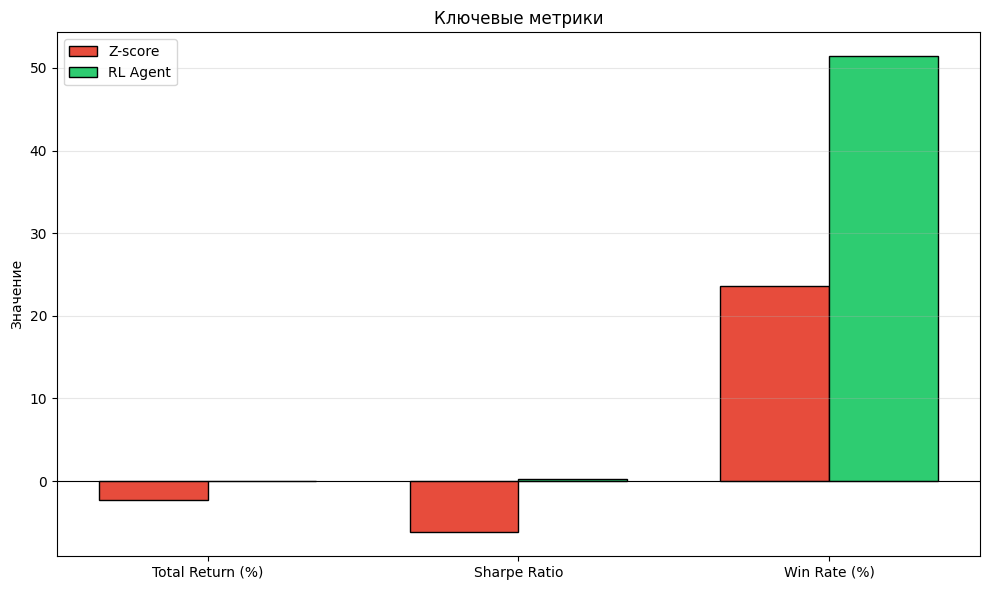

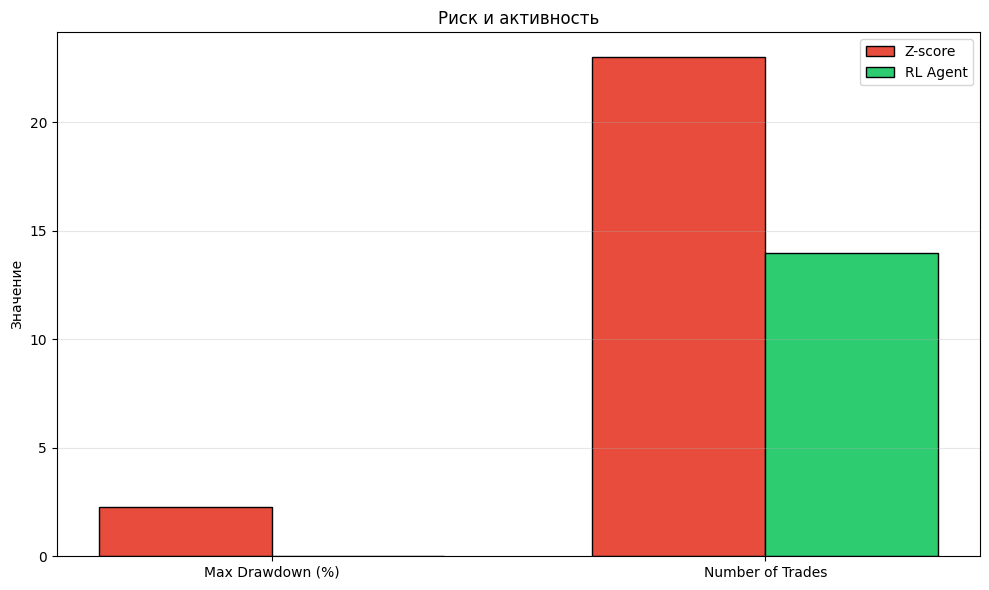

In [7]:
# График 1: Total Return, Sharpe Ratio, Win Rate
metrics_1 = ['Total Return (%)', 'Sharpe Ratio', 'Win Rate (%)']
zscore_1 = [
    baseline['total_return'] * 100,      # -2.26%
    baseline['sharpe_ratio'],             # -6.21
    baseline['win_rate'] * 100            # 23.64%
]
rl_1 = [
    rl_agent['total_return'] * 100,       # 0.0264%
    rl_agent['sharpe_ratio'],             # 0.282799
    rl_agent['win_rate'] * 100            # 51.4151%
]

# График 2: Max Drawdown, Number of Trades
metrics_2 = ['Max Drawdown (%)', 'Number of Trades']
zscore_2 = [
    abs(baseline['max_drawdown']) * 100,   # 2.26%
    baseline['trades']                     # 23
]
rl_2 = [
    abs(rl_agent['max_drawdown']) * 100,   # 0.0282%
    rl_agent['trades']                     # 14
]

# ЦВЕТА
zscore_color = '#E74C3C'  # красный
rl_color = '#2ECC71'      # зелёный


# ГРАФИК 1: КЛЮЧЕВЫЕ МЕТРИКИ

fig1, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_1))
width = 0.35

ax1.bar(x - width/2, zscore_1, width, label='Z-score', color=zscore_color, edgecolor='black')
ax1.bar(x + width/2, rl_1, width, label='RL Agent', color=rl_color, edgecolor='black')

ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_ylabel('Значение')
ax1.set_title('Ключевые метрики')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ГРАФИК 2: РИСК И АКТИВНОСТЬ

fig2, ax2 = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics_2))
width = 0.35

ax2.bar(x - width/2, zscore_2, width, label='Z-score', color=zscore_color, edgecolor='black')
ax2.bar(x + width/2, rl_2, width, label='RL Agent', color=rl_color, edgecolor='black')

ax2.set_ylabel('Значение')
ax2.set_title('Риск и активность')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_2)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Краткие выводы**

RL Agent показывает положительную доходность 0.03%, Z-score убыточен на 2.26%.

Sharpe Ratio у RL Agent положительный 0.28, что говорит о приемлемом соотношении риска и доходности. У Z-score показатель отрицательный минус 6.21, что крайне плохо.

Win Rate у RL Agent составляет 51.4%, что почти вдвое выше чем у Z-score с 23.6%.

Максимальная просадка у RL Agent всего 0.03%, тогда как у Z-score она достигает 2.26%. Это означает, что RL Agent теряет капитал в 75 раз меньше.

RL Agent совершает меньше сделок 14 против 23, но делает это с гораздо лучшим качеством.

**Итог**

RL Agent превосходит Z-score по всем метрикам. Он стабильнее, безопаснее и эффективнее.

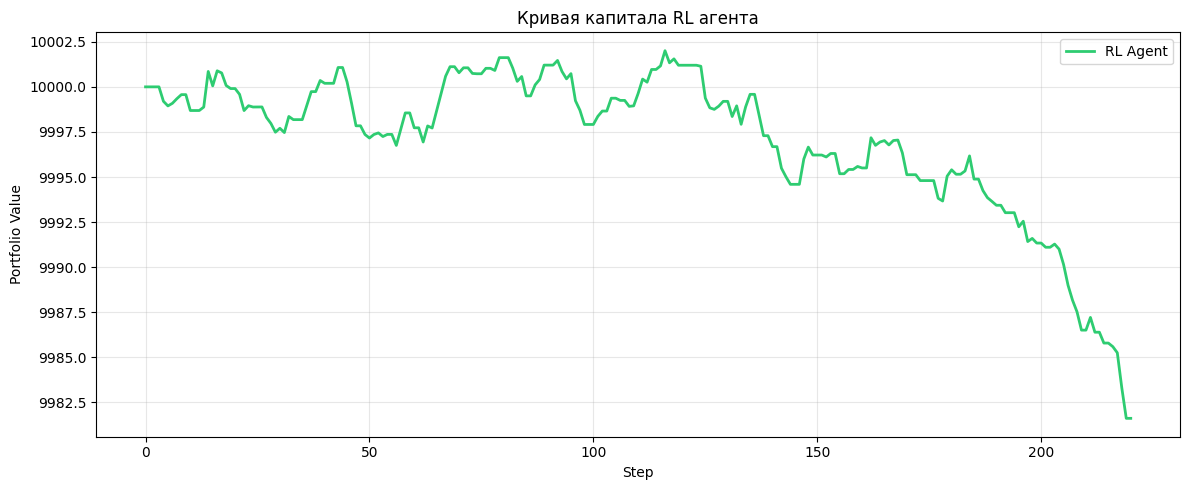

In [10]:
rl_result = download_history(
    config_path=str(config_path),
    dataset="rl",
)

raw_df = rl_result["data"]["merged"].copy()
raw_df = raw_df.rename(columns={"futures_close": "fut_close", "futures_volume": "fut_volume"})

feature_frame, features_scaled, scaler, feature_columns = build_feature_dataset(raw_df)

train_data, test_data = split_timeseries_data(
    feature_frame,
    features_scaled,
    train_ratio=0.7,
)

agent = QLearningAgent.load(model_path)

# кривая капитала RL агента
test_eval = evaluate_qlearning_agent(
    agent=agent,
    data=test_data,
    initial_capital=cfg.baseline.initial_capital,
    transaction_cost=cfg.baseline.transaction_cost,
    position_size_ratio=0.5,
)

rl_equity_curve = np.asarray(test_eval["portfolio"], dtype=float)

plt.figure(figsize=(12, 5))
plt.plot(rl_equity_curve, color="#2ECC71", linewidth=2, label="RL Agent")
plt.title("Кривая капитала RL агента")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()